In [2]:

!pip install transformers datasets evaluate seqeval accelerate -q

In [3]:
import os
import random
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import load_dataset
import evaluate

from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    DataCollatorForTokenClassification,
    TrainingArguments,
    Trainer,
    set_seed
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows", 200)

SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

MODEL_NAME = "distilbert-base-uncased"
DATASET_NAME = "universal_dependencies"
DATASET_CONFIG = "en_ewt"

TRAIN_SIZE = 500
VAL_SIZE = 150
TEST_SIZE = 150

MAX_LENGTH = 128
LEARNING_RATE = 2e-5
BATCH_SIZE = 16
EPOCHS = 1

device = "cuda" if torch.cuda.is_available() else "t4 gpu"
print("Using device:", device)


Using device: cuda


In [4]:
from datasets import load_dataset

DATASET_NAME = "commul/universal_dependencies"
DATASET_CONFIG = "en_ewt"

raw_datasets = load_dataset(DATASET_NAME, DATASET_CONFIG)

# Small subset for fast demo training
train_dataset = raw_datasets["train"].shuffle(seed=SEED).select(
    range(min(TRAIN_SIZE, len(raw_datasets["train"])))
)
val_dataset = raw_datasets["dev"].shuffle(seed=SEED).select(
    range(min(VAL_SIZE, len(raw_datasets["dev"])))
)
test_dataset = raw_datasets["test"].shuffle(seed=SEED).select(
    range(min(TEST_SIZE, len(raw_datasets["test"])))
)

print(raw_datasets)
print("\nSubset sizes:")
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

README.md: 0.00B [00:00, ?B/s]

parquet/en_ewt/dev.parquet:   0%|          | 0.00/516k [00:00<?, ?B/s]

parquet/en_ewt/test.parquet:   0%|          | 0.00/523k [00:00<?, ?B/s]

parquet/en_ewt/train.parquet:   0%|          | 0.00/3.60M [00:00<?, ?B/s]

Generating dev split:   0%|          | 0/2001 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2077 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/12544 [00:00<?, ? examples/s]

DatasetDict({
    dev: Dataset({
        features: ['sent_id', 'text', 'comments', 'tokens', 'lemmas', 'upos', 'xpos', 'feats', 'head', 'deprel', 'deps', 'misc', 'mwt', 'empty_nodes'],
        num_rows: 2001
    })
    test: Dataset({
        features: ['sent_id', 'text', 'comments', 'tokens', 'lemmas', 'upos', 'xpos', 'feats', 'head', 'deprel', 'deps', 'misc', 'mwt', 'empty_nodes'],
        num_rows: 2077
    })
    train: Dataset({
        features: ['sent_id', 'text', 'comments', 'tokens', 'lemmas', 'upos', 'xpos', 'feats', 'head', 'deprel', 'deps', 'misc', 'mwt', 'empty_nodes'],
        num_rows: 12544
    })
})

Subset sizes:
Train: 500
Validation: 150
Test: 150


In [5]:
# Identify label categories safely
upos_feature = raw_datasets["train"].features["upos"]

if hasattr(upos_feature, "feature") and hasattr(upos_feature.feature, "names"):
    label_list = upos_feature.feature.names
elif hasattr(upos_feature, "names"):
    label_list = upos_feature.names
else:
    # Fallback in case label metadata is not directly exposed
    unique_labels = set()
    for row in raw_datasets["train"]["upos"]:
        unique_labels.update(row)
    label_list = sorted(unique_labels)

label2id = {label: i for i, label in enumerate(label_list)}
id2label = {i: label for label, i in label2id.items()}

dataset_info_df = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Rows Used": [len(train_dataset), len(val_dataset), len(test_dataset)]
})

label_df = pd.DataFrame({
    "Label ID": list(range(len(label_list))),
    "POS Label": label_list
})

display(dataset_info_df)
display(label_df)
print("Total POS labels:", len(label_list))

,Split,Rows Used
0,Train,500
1,Validation,150
2,Test,150


,Label ID,POS Label
0,0,NOUN
1,1,PUNCT
2,2,ADP
3,3,NUM
4,4,SYM
5,5,SCONJ
6,6,ADJ
7,7,PART
8,8,DET
9,9,CCONJ


Total POS labels: 18


In [6]:
sample = train_dataset[0]
sample_df = pd.DataFrame({
    "Token": sample["tokens"],
    "UPOS_ID": sample["upos"],
    "UPOS_Label": [id2label[i] if isinstance(i, int) else i for i in sample["upos"]]
})

print("Sample sentence:")
print(" ".join(sample["tokens"]))
display(sample_df.head(20))

Sample sentence:
A key question is how they acquired the anthrax strain first isolated by the Texas Veterinary Medical Diagnostic Lab in 1980 .


,Token,UPOS_ID,UPOS_Label
0,A,8,DET
1,key,6,ADJ
2,question,0,NOUN
3,is,17,AUX
4,how,14,ADV
5,they,11,PRON
6,acquired,16,VERB
7,the,8,DET
8,anthrax,0,NOUN
9,strain,0,NOUN


In [7]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [8]:
def tokenize_and_align_labels(examples):
    tokenized_inputs = tokenizer(
        examples["tokens"],
        is_split_into_words=True,
        truncation=True,
        max_length=MAX_LENGTH
    )

    aligned_labels = []

    for batch_index, labels in enumerate(examples["upos"]):
        word_ids = tokenized_inputs.word_ids(batch_index=batch_index)
        previous_word_idx = None
        label_ids = []

        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100)
            elif word_idx != previous_word_idx:
                label_ids.append(labels[word_idx])
            else:
                label_ids.append(-100)
            previous_word_idx = word_idx

        aligned_labels.append(label_ids)

    tokenized_inputs["labels"] = aligned_labels
    return tokenized_inputs

In [9]:
from datasets import DatasetDict

subset_datasets = DatasetDict({
    "train": train_dataset,
    "validation": val_dataset,
    "test": test_dataset
})

tokenized_datasets = subset_datasets.map(
    tokenize_and_align_labels,
    batched=True,
    remove_columns=subset_datasets["train"].column_names
)

tokenized_datasets

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/150 [00:00<?, ? examples/s]

Map:   0%|          | 0/150 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 500
    })
    validation: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 150
    })
    test: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 150
    })
})

In [10]:
sample_tok = tokenized_datasets["train"][0]
tokens = tokenizer.convert_ids_to_tokens(sample_tok["input_ids"])

preview_df = pd.DataFrame({
    "Tokenized Token": tokens,
    "Input ID": sample_tok["input_ids"],
    "Attention Mask": sample_tok["attention_mask"],
    "Label ID": sample_tok["labels"],
    "Label Name": [
        "IGNORE(-100)" if x == -100 else id2label[int(x)]
        for x in sample_tok["labels"]
    ]
})

print("Sample tokenization output (required):")
display(preview_df.head(40))

Sample tokenization output (required):


,Tokenized Token,Input ID,Attention Mask,Label ID,Label Name
0,[CLS],101,1,-100,IGNORE(-100)
1,a,1037,1,8,DET
2,key,3145,1,6,ADJ
3,question,3160,1,0,NOUN
4,is,2003,1,17,AUX
5,how,2129,1,14,ADV
6,they,2027,1,11,PRON
7,acquired,3734,1,16,VERB
8,the,1996,1,8,DET
9,ant,14405,1,0,NOUN


In [11]:

model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id
).to(device)

config_preview_df = pd.DataFrame({
    "Config Item": ["model_name", "num_labels", "hidden_size", "max_position_embeddings"],
    "Value": [
        MODEL_NAME,
        model.config.num_labels,
        getattr(model.config, "dim", getattr(model.config, "hidden_size", "N/A")),
        model.config.max_position_embeddings
    ]
})

display(config_preview_df)

print("model.config.num_labels =", model.config.num_labels)
print("\nSample id2label mapping:")
for k in list(model.config.id2label.keys())[:10]:
    print(f"{k}: {model.config.id2label[k]}")


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForTokenClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


,Config Item,Value
0,model_name,distilbert-base-uncased
1,num_labels,18
2,hidden_size,768
3,max_position_embeddings,512


model.config.num_labels = 18

Sample id2label mapping:
0: NOUN
1: PUNCT
2: ADP
3: NUM
4: SYM
5: SCONJ
6: ADJ
7: PART
8: DET
9: CCONJ


In [12]:
data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)
seqeval = evaluate.load("seqeval")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=2)

    true_predictions = []
    true_labels = []

    for pred_seq, label_seq in zip(predictions, labels):
        pred_labels = []
        gold_labels = []
        for pred_id, label_id in zip(pred_seq, label_seq):
            if label_id != -100:
                pred_labels.append(id2label[int(pred_id)])
                gold_labels.append(id2label[int(label_id)])
        true_predictions.append(pred_labels)
        true_labels.append(gold_labels)

    results = seqeval.compute(predictions=true_predictions, references=true_labels)

    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
        "accuracy": results["overall_accuracy"]
    }

In [13]:
from transformers import TrainingArguments
import pandas as pd
import torch

training_args = TrainingArguments(
    output_dir="./distilbert_pos_output",
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=EPOCHS,
    weight_decay=0.01,
    logging_steps=5,
    save_strategy="no",
    eval_strategy="no",   # <- fixed here
    report_to="none",
    fp16=torch.cuda.is_available(),
    dataloader_pin_memory=torch.cuda.is_available(),
    seed=SEED
)

training_config_df = pd.DataFrame({
    "Parameter": [
        "Model", "Train rows", "Validation rows", "Test rows", "Epochs",
        "Batch size", "Max length", "Learning rate", "FP16"
    ],
    "Value": [
        MODEL_NAME,
        len(tokenized_datasets["train"]),
        len(tokenized_datasets["validation"]),
        len(tokenized_datasets["test"]),
        EPOCHS,
        BATCH_SIZE,
        MAX_LENGTH,
        LEARNING_RATE,
        torch.cuda.is_available()
    ]
})

display(training_config_df)

,Parameter,Value
0,Model,distilbert-base-uncased
1,Train rows,500
2,Validation rows,150
3,Test rows,150
4,Epochs,1
5,Batch size,16
6,Max length,128
7,Learning rate,0.00002
8,FP16,True


In [14]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],   # or ["dev"] if you kept UD split names
    processing_class=tokenizer,                      # <- fixed here
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [15]:
train_result = trainer.train()
train_result

Step,Training Loss
5,2.820524
10,2.665096
15,2.512019
20,2.424779
25,2.350615
30,2.316751


TrainOutput(global_step=32, training_loss=2.4990761280059814, metrics={'train_runtime': 2.825, 'train_samples_per_second': 176.99, 'train_steps_per_second': 11.327, 'total_flos': 6043433006160.0, 'train_loss': 2.4990761280059814, 'epoch': 1.0})

,step,loss
0,5,2.820524
1,10,2.665096
2,15,2.512019
3,20,2.424779
4,25,2.350615
5,30,2.316751


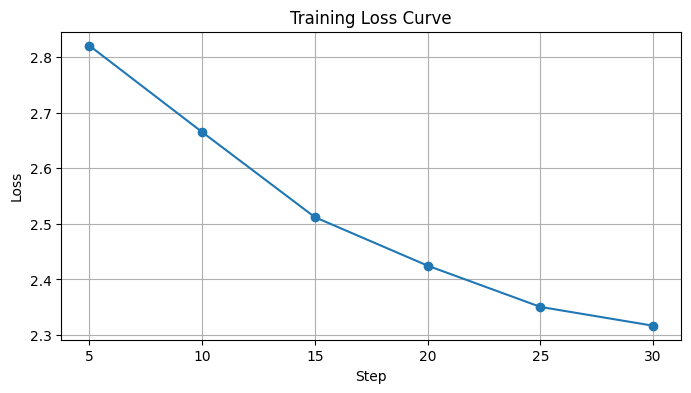

In [16]:
log_history = trainer.state.log_history
loss_points = [entry for entry in log_history if "loss" in entry]

if len(loss_points) > 0:
    loss_df = pd.DataFrame(loss_points)[["step", "loss"]]
    display(loss_df)

    plt.figure(figsize=(8, 4))
    plt.plot(loss_df["step"], loss_df["loss"], marker="o")
    plt.title("Training Loss Curve")
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.show()
else:
    print("No loss logs available to plot.")

In [17]:

test_metrics = trainer.predict(tokenized_datasets["test"]).metrics

metrics_df = pd.DataFrame({
    "Metric": ["Precision", "Recall", "F1 Score", "Accuracy"],
    "Value": [
        round(test_metrics.get("test_precision", 0), 4),
        round(test_metrics.get("test_recall", 0), 4),
        round(test_metrics.get("test_f1", 0), 4),
        round(test_metrics.get("test_accuracy", 0), 4)
    ]
})

display(metrics_df)
print(test_metrics)

,Metric,Value
0,Precision,0.3715
1,Recall,0.1927
2,F1 Score,0.2538
3,Accuracy,0.3456


{'test_loss': 2.3039045333862305, 'test_precision': 0.3715319662243667, 'test_recall': 0.1927409261576971, 'test_f1': 0.25381128965801397, 'test_accuracy': 0.34557109557109555, 'test_runtime': 0.2283, 'test_samples_per_second': 657.165, 'test_steps_per_second': 43.811}


In [18]:
def predict_pos_tags(sentence, model, tokenizer, id2label, max_length=128):
    model.eval()
    words = sentence.split()

    encoding = tokenizer(
        words,
        is_split_into_words=True,
        return_tensors="pt",
        truncation=True,
        max_length=max_length
    )

    encoding = {k: v.to(model.device) for k, v in encoding.items()}

    with torch.no_grad():
        outputs = model(**encoding)

    predictions = torch.argmax(outputs.logits, dim=-1).squeeze().tolist()
    if isinstance(predictions, int):
        predictions = [predictions]

    word_ids = tokenizer(
        words,
        is_split_into_words=True,
        truncation=True,
        max_length=max_length
    ).word_ids()

    final_words = []
    final_tags = []
    previous_word_idx = None

    for pred_id, word_idx in zip(predictions, word_ids):
        if word_idx is None:
            continue
        if word_idx != previous_word_idx:
            final_words.append(words[word_idx])
            final_tags.append(id2label[int(pred_id)])
        previous_word_idx = word_idx

    return pd.DataFrame({
        "Word": final_words,
        "Predicted_POS": final_tags
    })

sentences = [
    "John works at Google in California",
    "The quick brown fox jumps over the lazy dog",
    "Harsha is learning NLP with DistilBERT today"
]

for i, sentence in enumerate(sentences, start=1):
    print(f"Example {i}: {sentence}")
    display(predict_pos_tags(sentence, model, tokenizer, id2label, max_length=MAX_LENGTH))

Example 1: John works at Google in California


,Word,Predicted_POS
0,John,NOUN
1,works,NOUN
2,at,PRON
3,Google,NOUN
4,in,NOUN
5,California,NOUN


Example 2: The quick brown fox jumps over the lazy dog


,Word,Predicted_POS
0,The,NOUN
1,quick,NOUN
2,brown,NOUN
3,fox,NOUN
4,jumps,NOUN
5,over,VERB
6,the,NOUN
7,lazy,NOUN
8,dog,NOUN


Example 3: Harsha is learning NLP with DistilBERT today


,Word,Predicted_POS
0,Harsha,NOUN
1,is,NOUN
2,learning,NOUN
3,NLP,NOUN
4,with,NOUN
5,DistilBERT,NOUN
6,today,NOUN
